In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression

In [107]:
diabetes = load_diabetes()
print(diabetes.keys())
print(f"Feature Names: {diabetes["feature_names"]}")
print(diabetes.data.shape)

df=pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target

print(df.isnull().sum())
df.describe()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])
Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
(442, 10)
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


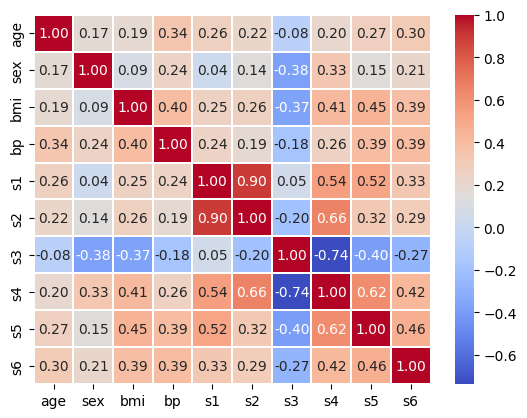

In [108]:
corr_matrix = df[diabetes.feature_names].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f",cmap="coolwarm",linewidths=0.2)
plt.show()
plt.close()

In [109]:
X = df[diabetes.feature_names]
y = df["target"]
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [110]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.mean(axis=0).round(2))
print(X_test_scaled.std(axis=0).round(2))

[-0. -0. -0.  0. -0. -0.  0. -0. -0.  0.]
[1.12 1.   1.02 0.9  0.98 1.   1.06 0.98 0.97 0.9 ]


In [111]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)
print(f"Intercept: {model.intercept_:.4f}")
coef_df = pd.DataFrame({
    'feature': diabetes.feature_names,
    'coefficient': model.coef_
})
print(coef_df.sort_values('coefficient', ascending=False))

Intercept: 153.7365
  feature  coefficient
8      s5    35.161195
2     bmi    25.607121
5      s2    24.640954
3      bp    16.828872
7      s4    13.138784
6      s3     7.676978
9      s6     2.351364
0     age     1.753758
1     sex   -11.511809
4      s1   -44.448856


In [112]:
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE :{mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MSE :2900.1936
RMSE: 53.8534
R² Score: 0.4526


### Regularization - Ridge

In [113]:
ridge_cv = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100])
ridge_cv.fit(X_train_scaled, y_train)
print(f"Best alpha: {ridge_cv.alpha_}")
model = Ridge(alpha=ridge_cv.alpha_)

Best alpha: 1.0


In [114]:
model.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [115]:
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 53.7775
R²: 0.4541


In [116]:
coef_df = pd.DataFrame({
    'feature': diabetes.feature_names,
    'coefficient': model.coef_
   })
print(coef_df.sort_values('coefficient', ascending=False))

  feature  coefficient
8      s5    31.378384
2     bmi    25.732699
5      s2    17.053075
3      bp    16.734300
7      s4    11.764260
6      s3     3.369914
9      s6     2.458139
0     age     1.807342
1     sex   -11.448190
4      s1   -34.671954


### Lasso

In [117]:
lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100], cv=5)
lasso_cv.fit(X_train_scaled, y_train)
print(f"Best alpha: {lasso_cv.alpha_}")
model = Lasso(alpha=lasso_cv.alpha_)

Best alpha: 1.0


In [118]:
model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(1.0)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [119]:
coef_df = pd.DataFrame({
    'feature': diabetes.feature_names,
    'coefficient': model.coef_
   })
print(coef_df.sort_values('coefficient', ascending=False))

  feature  coefficient
2     bmi    26.219225
8      s5    22.636465
3      bp    15.657314
7      s4     3.420861
9      s6     2.098647
0     age     0.687032
5      s2    -0.000000
4      s1    -8.228172
6      s3    -9.024087
1     sex    -9.297519


In [120]:
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 53.1467
R²: 0.4669


In [121]:
lr_scores = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring='r2')
ridge_scores = cross_val_score(Ridge(alpha=1.0), X_train_scaled, y_train, cv=5, scoring='r2')
lasso_scores = cross_val_score(Lasso(alpha=1.0), X_train_scaled, y_train, cv=5, scoring='r2')

print(f"Linear Regression R²: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
print(f"Ridge R²: {ridge_scores.mean():.4f} (+/- {ridge_scores.std():.4f})")
print(f"Lasso R²: {lasso_scores.mean():.4f} (+/- {lasso_scores.std():.4f})")

Linear Regression R²: 0.4493 (+/- 0.1441)
Ridge R²: 0.4512 (+/- 0.1388)
Lasso R²: 0.4541 (+/- 0.1253)


### Training Curve

In [122]:
train_sizes, train_scores, val_scores = learning_curve(
    Lasso(alpha=lasso_cv.alpha_),
    X_train_scaled, y_train,
    cv=5, scoring="r2",
    train_sizes = np.linspace(0.1, 1.0, 10)
)

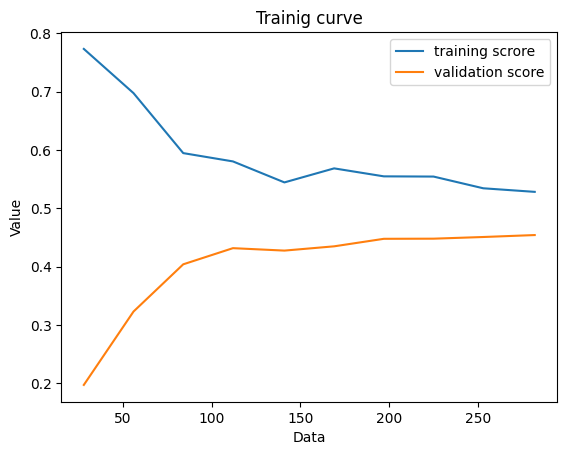

In [123]:
plt.plot(train_sizes, train_scores.mean(axis=1), label="training scrore")
plt.plot(train_sizes, val_scores.mean(axis=1), label="validation score")
plt.title("Trainig curve")
plt.legend()
plt.xlabel("Data")
plt.ylabel("Value")
plt.show()
plt.close()

### Polynomial Features

In [124]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [125]:
lasso_cv = LassoCV(alphas = [0.001, 0.01, 0.1, 1, 10, 100], cv=5, max_iter=350000)
lasso_cv.fit(X_train_poly, y_train)
model = Lasso(alpha=lasso_cv.alpha_)
model.fit(X_train_poly, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(1.0)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [126]:
y_pred = model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 50.5509
R²: 0.5177


Cross validation against non polynomial Lasso

In [127]:
lasso_scores = cross_val_score(Lasso(alpha=1.0), X_train_scaled, y_train, cv=5, scoring='r2')
lasso_poly_scores = cross_val_score(Lasso(alpha=1.0), X_train_poly, y_train, cv=5, scoring='r2')

print(f"Lasso R²: {lasso_scores.mean():.4f} (+/- {lasso_scores.std():.4f})")
print(f"Lasso Poly R²: {lasso_poly_scores.mean():.4f} (+/- {lasso_poly_scores.std():.4f})")

Lasso R²: 0.4541 (+/- 0.1253)
Lasso Poly R²: 0.4127 (+/- 0.1529)


In [128]:
selector = SelectKBest(score_func=f_regression, k=5)


# Fit on training data — learns which features are most correlated with target
selector.fit(X_train_scaled, y_train)

# Transform both sets — keeps only the selected features
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

# See which features were selected
selected = selector.get_support()
print(np.array(diabetes.feature_names)[selected])

# See the scores for each feature
scores = pd.DataFrame({
    'feature': diabetes.feature_names,
    'score': selector.scores_
})
print(scores.sort_values('score', ascending=False))

['bmi' 'bp' 's4' 's5' 's6']
  feature       score
2     bmi  202.386965
8      s5  153.967806
3      bp   86.558038
7      s4   77.417118
9      s6   63.102304
6      s3   60.708775
4      s1   14.556110
0     age   14.098670
5      s2    8.631430
1     sex    0.017776


In [129]:
lasso_cv.fit(X_train_selected, y_train)
model = Lasso(alpha=lasso_cv.alpha_)
model.fit(X_train_selected, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(1.0)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [130]:
y_pred = model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 53.7597
R²: 0.4545


In [132]:
lasso_scores = cross_val_score(Lasso(alpha=1.0), X_train_scaled, y_train, cv=5, scoring='r2')
lasso_poly_scores = cross_val_score(Lasso(alpha=1.0), X_train_poly, y_train, cv=5, scoring='r2')
lasso_sel_scores = cross_val_score(Lasso(alpha=1.0), X_train_selected, y_train, cv=5, scoring='r2')

print(f"Lasso R²: {lasso_scores.mean():.4f} (+/- {lasso_scores.std():.4f})")
print(f"Lasso Poly R²: {lasso_poly_scores.mean():.4f} (+/- {lasso_poly_scores.std():.4f})")
print(f"Lasso Selected R²: {lasso_sel_scores.mean():.4f} (+/- {lasso_sel_scores.std():.4f})")

Lasso R²: 0.4541 (+/- 0.1253)
Lasso Poly R²: 0.4127 (+/- 0.1529)
Lasso Selected R²: 0.4318 (+/- 0.1060)
